In [27]:
import os
import requests
import time
import pandas as pd
import matplotlib.pyplot as plt

API_URL = os.getenv("LITELLM_URL", "http://localhost:8088/v1/chat/completions")
API_KEY = os.getenv("LITELLM_MASTER_KEY", "sk-fase0-local")
MODEL = os.getenv("LITELLM_MODEL", "local-chat")
THINK = os.getenv("LITELLM_THINK", "false").lower() == "true"

def measure_request(prompt):
    payload = {
       "model": MODEL,
       "messages": [{"role": "user", "content": prompt}],
       "max_tokens": 40,
       "think": THINK,
    }   
    
    start_time = time.time()
    # Usamos requests.post para ejecutar de verdad la petición
    response = requests.post(API_URL, json=payload, headers={
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json"
    })
    end_time = time.time()
    
    latency = end_time - start_time
    
    # Extraemos la respuesta y el estado de la caché
    res_json = response.json()
    answer = res_json['choices'][0]['message']['content']
    is_cache = response.headers.get("x-litellm-cache-hit") == "True"
    
    return latency, is_cache, answer

In [28]:
prompts = ["¿Qué es la computación distribuida?", "Explica el teorema de CAP"]
results = []

for p in prompts:
    print(f"Probando: {p}")
    # 1. Primera vez: CACHE MISS (Inferencia real)
    lat, cached, answer = measure_request(p)
    results.append({"prompt": p, "latencia": lat, "tipo": "Inferencia (Ollama)"})
    print(f"Respuesta: {answer[:100]}...")

    # 2. Segunda vez: CACHE HIT (Redis)
    lat, cached, answer = measure_request(p)
    results.append({"prompt": p, "latencia": lat, "tipo": "Caché (Redis)"})
    print(f"Respuesta: {answer[:100]}...")

df = pd.DataFrame(results)
display(df)

Probando: ¿Qué es la computación distribuida?
Respuesta: La **computación distribuida** es un conjunto de conceptos y tecnologías diseñadas para dividir tare...
Respuesta: La **computación distribuida** es un conjunto de conceptos y tecnologías diseñadas para dividir tare...
Probando: Explica el teorema de CAP
Respuesta: El **Teorema de CAP** (que en su origen se refería originalmente al Teorema de Cabello, un algoritmo...
Respuesta: El **Teorema de CAP** (que en su origen se refería originalmente al Teorema de Cabello, un algoritmo...


,prompt,latencia,tipo
0,¿Qué es la computación distribuida?,6.048521,Inferencia (Ollama)
1,¿Qué es la computación distribuida?,0.006488,Caché (Redis)
2,Explica el teorema de CAP,3.935697,Inferencia (Ollama)
3,Explica el teorema de CAP,0.005712,Caché (Redis)


<Figure size 1000x600 with 0 Axes>

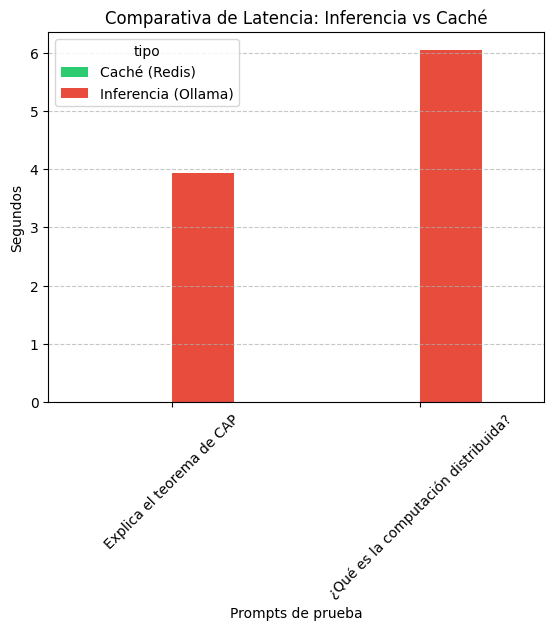

In [29]:
plt.figure(figsize=(10, 6))
pivot_df = df.pivot(index='prompt', columns='tipo', values='latencia')

pivot_df.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Comparativa de Latencia: Inferencia vs Caché')
plt.ylabel('Segundos')
plt.xlabel('Prompts de prueba')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()